Alternative: Provided an improved NN structure, where:
- NN has one output only
- eta is a learnable parameter
- softplus on final layer to enforce non-negativity constraint of the $\gamma xy$ factor

# Notebook Introduction

Consider the Lotka-Volterra equations for a predator-prey dynamics:

$$
\begin{align}
& \dot x = \alpha x - \gamma xy \\
& \dot y = -\beta y + \eta (\gamma xy)
\end{align}
$$

Suppose we only know $\alpha, \beta$ and $\eta$, how can we approximate the term $\gamma xy$? In this case we will use and implement the *Universal Differential Equations* according to [1] in Python.

In particular, we will:
1. Generate a synthetic dataset by fixing the parameters first
2. Consider the L-V equations only with $\alpha, \beta, \eta$ known; the term $\gamma xy$ will be approximated with a Neural Network defined as $\texttt{NN}(\theta, t)$
3. Train the Neural Network with the method described in the paper, in particular using numerical integration of ODEs (Newton's first-order method) 

The loss used to train the NN will be the MSE loss, defined as 

$$
\mathcal L_{\texttt{MSE} }(\theta) := \frac{1}{N} \sum_{i = 1, \ldots, n} [(\hat x_\theta(t_i) - x_i)^2 + (\hat y_\theta(t_i) - y_i)^2]
$$

Where $\hat x_\theta, \hat y_\theta$ are the solutions of the following parametrised DE in a certain time interval $[0, T]$:

$$
\begin{align}
& \dot x = \alpha x - \texttt{NN}(\theta, t) \\
& \dot y = -\beta y + \phi \cdot \texttt{NN}(\theta, t)
\end{align}
$$


In [1]:
# Libraries
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from torch import nn, optim 
import torch
from torchdiffeq import odeint
import pysindy as ps

if torch.cuda.is_available():
    device = "cuda:0"

else:
    device ="cpu"

device="cpu"

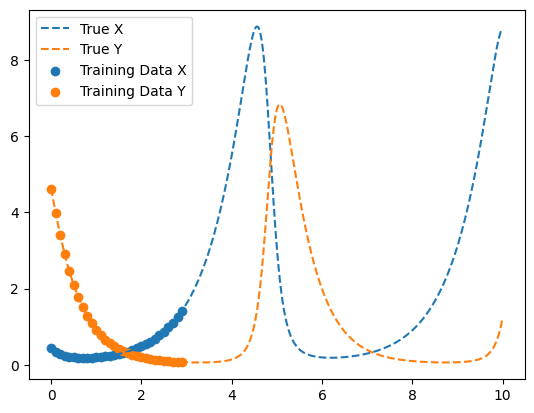

In [2]:
# Part 1: Synthetic Data Generation
alpha = 1.3
delta = 1.8
beta = 0.9
gamma = 0.8

def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.44249296, 4.6280594)

sol = solve_ivp(lotka_volterra, t_span = [0, 10], t_eval=np.arange(0, 10, 0.01), args=(alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

plt.plot(T, X, "--", label="True X")
plt.plot(T, Y, "--", label="True Y")

T_train = T[:300:10]
X_train = X[:300:10]
Y_train = Y[:300:10]

plt.scatter(T_train, X_train, label="Training Data X")
plt.scatter(T_train, Y_train, label="Training Data Y")

plt.legend()

plt.show()




In [3]:
# Define UDE

class universal_LV(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.a = a 
        self.b = b

        self.register_buffer("scale_dynamics", torch.tensor([a, -b], dtype=torch.float32, device=device))

        self.register_parameter("phi", nn.Parameter(torch.tensor([0.], requires_grad=True)))

        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32), 
            nn.SiLU(),
            nn.Linear(32, 1),
        ) 


    def forward(self, t, data):
        out_net = self.net(data)   

        scale_net = torch.stack([
            -1 * torch.tensor([1.]), 
            nn.functional.softplus(self.phi) # enforce non-negativity constraint with softplus
        ])                                     

        out_net = out_net.repeat(2, 1)         # duplicate along first dim
        out_net = out_net * scale_net

        summ = data * self.scale_dynamics

        out_net = out_net.reshape(1, 2)
        return out_net + summ
    
class neural_LV(nn.Module):
    # other case: full NN approach
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.SiLU(),
            nn.Linear(16, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 16), 
            nn.SiLU(),
            nn.Linear(16, 2)
        ) 

    def forward(self, t, data):
        return self.net(data)


In [164]:
# Train UDE network to training data

from tqdm import tqdm 
my_lv = universal_LV(alpha, delta)
my_lv = my_lv.to(device)


lr = 0.008
optimizer = torch.optim.Adam(my_lv.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1, 2000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.norm((info - torch.stack([X_train_torch, Y_train_torch], dim=1)), 2)**2
    loss_norm = loss_norm / T_train.shape[0]
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1: MSE Loss (L2 norm)= 2.982E+01
Epoch 2: MSE Loss (L2 norm)= 1.568E+01
Epoch 3: MSE Loss (L2 norm)= 5.188E+00
Epoch 4: MSE Loss (L2 norm)= 4.474E-02
Epoch 5: MSE Loss (L2 norm)= 4.686E+00
Epoch 6: MSE Loss (L2 norm)= 5.212E+00
Epoch 7: MSE Loss (L2 norm)= 1.929E+00
Epoch 8: MSE Loss (L2 norm)= 1.393E-01
Epoch 9: MSE Loss (L2 norm)= 2.918E-01
Epoch 10: MSE Loss (L2 norm)= 1.210E+00
Epoch 11: MSE Loss (L2 norm)= 1.870E+00
Epoch 12: MSE Loss (L2 norm)= 1.918E+00
Epoch 13: MSE Loss (L2 norm)= 1.481E+00
Epoch 14: MSE Loss (L2 norm)= 8.515E-01
Epoch 15: MSE Loss (L2 norm)= 3.143E-01
Epoch 16: MSE Loss (L2 norm)= 5.012E-02
Epoch 17: MSE Loss (L2 norm)= 9.451E-02
Epoch 18: MSE Loss (L2 norm)= 3.365E-01
Epoch 19: MSE Loss (L2 norm)= 5.821E-01
Epoch 20: MSE Loss (L2 norm)= 6.799E-01
Epoch 21: MSE Loss (L2 norm)= 6.002E-01
Epoch 22: MSE Loss (L2 norm)= 4.117E-01
Epoch 23: MSE Loss (L2 norm)= 2.133E-01
Epoch 24: MSE Loss (L2 norm)= 7.918E-02
Epoch 25: MSE Loss (L2 norm)= 3.730E-02
Epoch 26:

In [165]:
for group in optimizer.param_groups:
    group['lr'] = 0.002


for EPOCH in (range(2000, 4000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.norm((info - torch.stack([X_train_torch, Y_train_torch], dim=1)), 2)**2
    loss_norm = loss_norm / T_train.shape[0]
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 2000: MSE Loss (L2 norm)= 5.635E-04
Epoch 2001: MSE Loss (L2 norm)= 5.630E-04
Epoch 2002: MSE Loss (L2 norm)= 5.627E-04
Epoch 2003: MSE Loss (L2 norm)= 5.624E-04
Epoch 2004: MSE Loss (L2 norm)= 5.620E-04
Epoch 2005: MSE Loss (L2 norm)= 5.615E-04
Epoch 2006: MSE Loss (L2 norm)= 5.612E-04
Epoch 2007: MSE Loss (L2 norm)= 5.609E-04
Epoch 2008: MSE Loss (L2 norm)= 5.604E-04
Epoch 2009: MSE Loss (L2 norm)= 5.600E-04
Epoch 2010: MSE Loss (L2 norm)= 5.597E-04
Epoch 2011: MSE Loss (L2 norm)= 5.595E-04
Epoch 2012: MSE Loss (L2 norm)= 5.589E-04
Epoch 2013: MSE Loss (L2 norm)= 5.586E-04
Epoch 2014: MSE Loss (L2 norm)= 5.582E-04
Epoch 2015: MSE Loss (L2 norm)= 5.579E-04
Epoch 2016: MSE Loss (L2 norm)= 5.576E-04
Epoch 2017: MSE Loss (L2 norm)= 5.571E-04
Epoch 2018: MSE Loss (L2 norm)= 5.568E-04
Epoch 2019: MSE Loss (L2 norm)= 5.564E-04
Epoch 2020: MSE Loss (L2 norm)= 5.560E-04
Epoch 2021: MSE Loss (L2 norm)= 5.557E-04
Epoch 2022: MSE Loss (L2 norm)= 5.553E-04
Epoch 2023: MSE Loss (L2 norm)= 5.

In [166]:
torch.save(my_lv.state_dict(), "./tmp/my_lv_checkpoint1.mige")

In [167]:
lr = 0.0001
optimizer = torch.optim.SGD(my_lv.parameters(), lr)

for EPOCH in (range(4000, 5000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.norm((info - torch.stack([X_train_torch, Y_train_torch], dim=1)), 2)**2
    loss_norm = loss_norm / T_train.shape[0]
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 4000: MSE Loss (L2 norm)= 1.722E-04
Epoch 4001: MSE Loss (L2 norm)= 1.655E-04
Epoch 4002: MSE Loss (L2 norm)= 1.597E-04
Epoch 4003: MSE Loss (L2 norm)= 1.567E-04
Epoch 4004: MSE Loss (L2 norm)= 1.499E-04
Epoch 4005: MSE Loss (L2 norm)= 1.455E-04
Epoch 4006: MSE Loss (L2 norm)= 1.424E-04
Epoch 4007: MSE Loss (L2 norm)= 1.397E-04
Epoch 4008: MSE Loss (L2 norm)= 1.365E-04
Epoch 4009: MSE Loss (L2 norm)= 1.352E-04
Epoch 4010: MSE Loss (L2 norm)= 1.324E-04
Epoch 4011: MSE Loss (L2 norm)= 1.305E-04
Epoch 4012: MSE Loss (L2 norm)= 1.291E-04
Epoch 4013: MSE Loss (L2 norm)= 1.286E-04
Epoch 4014: MSE Loss (L2 norm)= 1.274E-04
Epoch 4015: MSE Loss (L2 norm)= 1.255E-04
Epoch 4016: MSE Loss (L2 norm)= 1.246E-04
Epoch 4017: MSE Loss (L2 norm)= 1.239E-04
Epoch 4018: MSE Loss (L2 norm)= 1.234E-04
Epoch 4019: MSE Loss (L2 norm)= 1.227E-04
Epoch 4020: MSE Loss (L2 norm)= 1.222E-04
Epoch 4021: MSE Loss (L2 norm)= 1.218E-04
Epoch 4022: MSE Loss (L2 norm)= 1.214E-04
Epoch 4023: MSE Loss (L2 norm)= 1.

In [168]:
torch.save(my_lv.state_dict(), "./tmp/my_lv_checkpoint2.mige")

In [4]:
my_lv = universal_LV(alpha, delta)
my_lv.load_state_dict(torch.load("./tmp/my_lv_checkpoint2.mige"))

<All keys matched successfully>

In [5]:
my_lv.phi

Parameter containing:
tensor([0.3200], requires_grad=True)

In [170]:
# Train neural ODE network to training data
my_neural_lv = neural_LV()
my_neural_lv = my_neural_lv.to(device)

from tqdm import tqdm 

lr = 0.01
n_optimizer = torch.optim.Adam(my_neural_lv.net.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1, 2000)):
    n_optimizer.zero_grad()

    # get forward solution
    info = odeint(my_neural_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - torch.stack([X_train_torch, Y_train_torch], dim=1)), 2)**2
    loss_norm = loss_norm / T_train.shape[0]
    loss_norm.backward()

    n_optimizer.step()

    with torch.no_grad():
        
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1: MSE Loss (L2 norm)= 1.222E+01
Epoch 2: MSE Loss (L2 norm)= 1.079E+01
Epoch 3: MSE Loss (L2 norm)= 8.925E+00
Epoch 4: MSE Loss (L2 norm)= 6.550E+00
Epoch 5: MSE Loss (L2 norm)= 3.965E+00
Epoch 6: MSE Loss (L2 norm)= 1.827E+00
Epoch 7: MSE Loss (L2 norm)= 8.032E-01
Epoch 8: MSE Loss (L2 norm)= 8.746E-01
Epoch 9: MSE Loss (L2 norm)= 1.189E+00
Epoch 10: MSE Loss (L2 norm)= 1.300E+00
Epoch 11: MSE Loss (L2 norm)= 1.314E+00
Epoch 12: MSE Loss (L2 norm)= 1.332E+00
Epoch 13: MSE Loss (L2 norm)= 1.304E+00
Epoch 14: MSE Loss (L2 norm)= 1.172E+00
Epoch 15: MSE Loss (L2 norm)= 9.577E-01
Epoch 16: MSE Loss (L2 norm)= 7.136E-01
Epoch 17: MSE Loss (L2 norm)= 4.894E-01
Epoch 18: MSE Loss (L2 norm)= 3.185E-01
Epoch 19: MSE Loss (L2 norm)= 2.153E-01
Epoch 20: MSE Loss (L2 norm)= 1.766E-01
Epoch 21: MSE Loss (L2 norm)= 1.860E-01
Epoch 22: MSE Loss (L2 norm)= 2.206E-01
Epoch 23: MSE Loss (L2 norm)= 2.586E-01
Epoch 24: MSE Loss (L2 norm)= 2.842E-01
Epoch 25: MSE Loss (L2 norm)= 2.889E-01
Epoch 26:

In [171]:
torch.save(my_neural_lv.state_dict(), "./tmp/my_lv_checkpoint_nde.mige")

In [6]:
# skip above if already trained
my_neural_lv = neural_LV()
my_neural_lv.load_state_dict(torch.load(r"./tmp/my_lv_checkpoint_nde.mige"))


<All keys matched successfully>

In [34]:
x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)

Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)


In [35]:
pred = odeint(my_lv, x0_torch, T_train_torch, method='dopri5', atol=1e-5, rtol=1e-5)
pred_neural = odeint(my_neural_lv, x0_torch, T_train_torch)

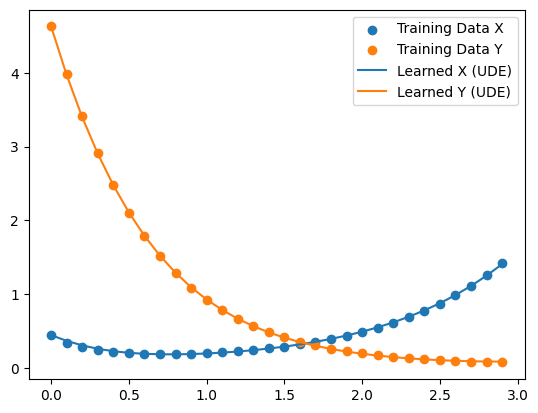

In [36]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred[:, 0].cpu().detach().numpy(), label="Learned X (UDE)")
plt.plot(T_train, pred[:, 1].cpu().detach().numpy(), label="Learned Y (UDE)")

plt.legend()

plt.show()


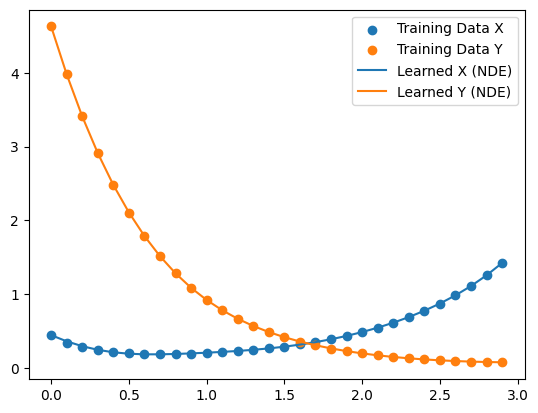

In [15]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred_neural[:, 0].cpu().detach().numpy(), label="Learned X (NDE)")
plt.plot(T_train, pred_neural[:, 1].cpu().detach().numpy(), label="Learned Y (NDE)")

plt.legend()

plt.show()


In [22]:
# Train SINDy with the known derivatives now!
# UDEs

pred_new = odeint(my_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 3, 0.01))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.256 x + -0.815 x y
(y)' = -1.729 y +  0.506 x y


In [23]:
# do the same thing with NDE
pred_new = odeint(my_neural_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 3, 0.01))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_neural_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.305 x + -0.861 x y
(y)' = -1.761 y +  0.642 x y


In [24]:
# What if we trained SINDy without UDE-enhanched derivatives

sol = solve_ivp(lotka_volterra, t_span = [0, 20], t_eval=np.arange(0, 20, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

T_train_ps = T[:300:10]
X_train_ps = X[:300:10]
Y_train_ps = Y[:300:10]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    # x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

# Even by manipulating the STLSQ coefficient we won't be able to get rid of the quadratic and cubic term of the unneccessary coefficients

(x)' =  1.248 x +  0.124 x^2 + -0.885 x y + -0.066 x^3
(y)' = -1.800 y +  0.787 x y


In [22]:
# plotl earned dynamics

In [221]:
X_train.min()

np.float64(0.18652973239253132)

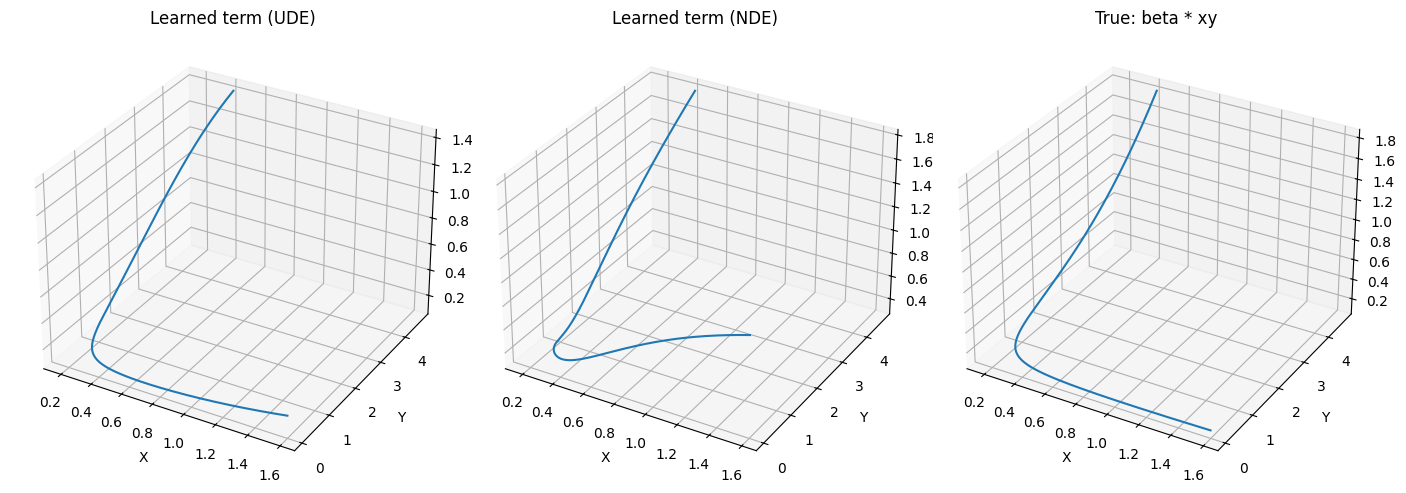

In [247]:
# Make plots
T_train = T[:300:1]
X_train = X[:300:1]
Y_train = Y[:300:1]


X_pts = np.asarray(X_train).ravel()
Y_pts = np.asarray(Y_train).ravel()

punti_input = np.stack([X_pts, Y_pts], axis=-1)
input_tensor = torch.tensor(punti_input, dtype=torch.float32)

with torch.no_grad():
    z_pred = my_lv.net(input_tensor).squeeze()
    Z_nn = z_pred.numpy()

    z_ude_pred = my_neural_lv(0, input_tensor)[:, 0]
    Z_ude_nn = -z_ude_pred.numpy() + 2 * X_pts   # extrapolate dynamics by applying some ad-hoc transformations

# True function
Z_true = beta * X_pts * Y_pts

fig = plt.figure(figsize=(14, 5))

# Plot UDE
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X_pts, Y_pts, Z_nn)
ax1.set_title('Learned term (UDE)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot NDE
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(X_pts, Y_pts, Z_ude_nn)
ax2.set_title('Learned term (NDE)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

# Plot true
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(X_pts, Y_pts, Z_true)
ax3.set_title('True: beta * xy')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')

plt.tight_layout()
plt.show()

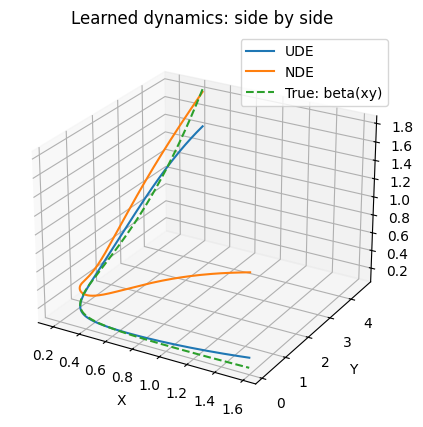

In [248]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X_pts, Y_pts, Z_nn, label='UDE')
ax.plot(X_pts, Y_pts, Z_ude_nn, label='NDE')
ax.plot(X_pts, Y_pts, Z_true, "--", label='True: beta(xy)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(elev=25, azim=-60)
ax.legend()

plt.title("Learned dynamics: side by side")
plt.show()

In [241]:
torch.save(my_lv.state_dict(), "my_lv_ude_weights_alt_alt.dinomeng")
torch.save(my_neural_lv.state_dict(), "my_lv_nde_weights_alt_alt.dinomeng")


# References

[1] C. Rackauckas et al., ‘Universal Differential Equations for Scientific Machine Learning’, Aug. 31, 2020, In Review. doi: 10.21203/rs.3.rs-55125/v1.
